# PyTorch Workflow

Let's explore an example Pytorch end-to-end workflow.

Resources:
* Ground truth notebook - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* Book version of notebook - https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data(training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data(training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check Pytorch version
torch.__version__

'2.11.0'

## 1. Data (preparing and loading)
Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representaion.

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with *known* **parameters**.

In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set with our data.

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len (X_test), len (y_test)

(40, 40, 10, 10)

How might we better visualize our data?


In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data and compares predictions
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

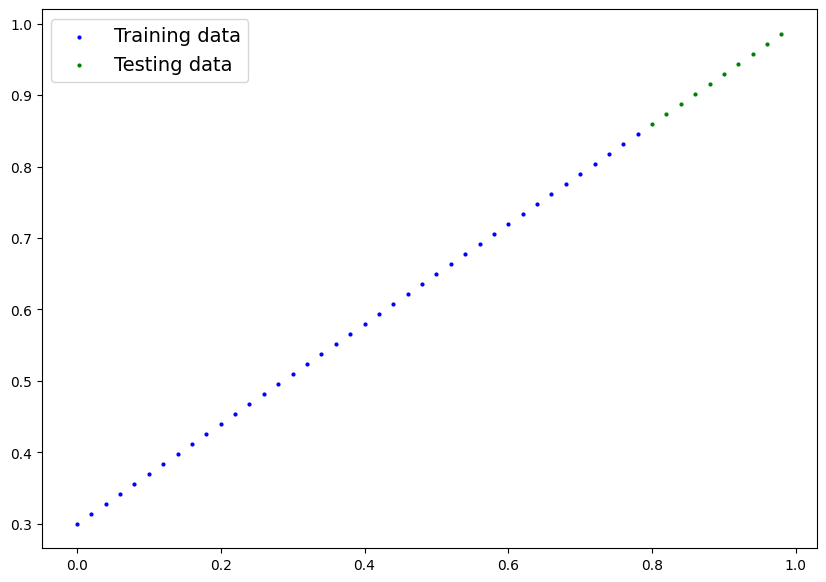

In [7]:
plot_predictions();

## 2. Build Model

Building classes; OOP in Python resource: https://realpython.com/python-classes/

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the radom values to better represent (or get closer to) the ideal values (the weight & bias values we use dto create the data).

How does it do so?

Through two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w?si=yZMsa3Pq4aqTpKhd
2. Backpropagation - https://www.youtube.com/watch?v=Ilg3gGewQ5U 

In [49]:
from torch import nn

# Create a linear regression model class

class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module (Base class for all neural network modules)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this parameter be updated via gradient descent?
                                               dtype=torch.float)) # <- PyTorch loves the datatype torch.float2

        self.bias = nn.Parameter(torch.rand(1, # <- start with a random bias and try to adjust it to the ideal bias
        requires_grad=True, # <- can this parameter be updated via gradient descent?
        dtype=torch.float)) # <- PyTorch loves the datatype torch.float2


    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula

 ### Pytorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a neural networks can be considered as a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us
* torch.nn.Module - the base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation.

### Checking the contents of our PyTorch Model

No we've created a model, let's see whats inside...

So we can check our model parameters or whats's inside our model using `.parameters()`

In [142]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [143]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [144]:
weight, bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.
https://x.com/PyTorch/status/1437838231505096708
When we pass data through our model, it's going to run it through the `forward()` method.

In [145]:
y_preds = model_0(X_test)
y_preds

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]], grad_fn=<AddBackward0>)

In [146]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [147]:
# Make predicitions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Can also do something similar with torch.no_grad(), however inference_mode() is preferred
# with torch.no_grad():
#     y_preds = model_0(X_test)

y_preds


tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]])

In [148]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

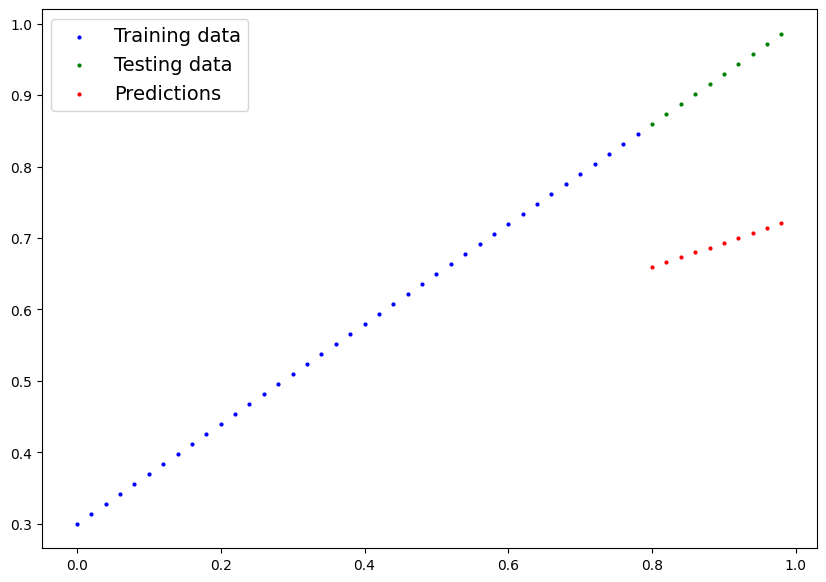

In [149]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters(these may be random) to some *known* parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your model predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're goin to refer to it as a loss function.

Thing we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function - https://docs.pytorch.org/docs/main/optim.html#module-torch.optim

And specifically for PyTorch, we need:

* A training loop
* A testing loop


In [150]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [151]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [152]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                           lr=0.01)  # lr = learning rate = possibly the most import hyperparameter you can set)



**Q:** Which loss funtion and optimizer should I use?
**A:** This will be problem specific. But with experience, uou'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem(like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss)

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop thrugh the data adn do...
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our models with respect to the loss (**backpropagation**)
6. Otpimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [154]:
torch.manual_seed(42)

# An epoch is one loop through the data... (this is a hyperparameter because we've set it ourselves)
epochs  = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs): 
    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    # print(f"Loss: {loss}")
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss w.r.t the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will accumulate through the loop so... we have to zero them above in step 3 for the next iteration of the loop.

    ### Testing
    model_0.eval() # turns off different settings in the model needed for evaluation/testing (dropout/batch norm layers)
    with torch.inference_mode(): # turns off gradient tracking & a couple of more things behind the scenes - https://x.com/PyTorch/status/1437838231505096708
    # with torch.no_grad(): # you may also see torch.no_grad() in older PyTorch code
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    # Print out whats's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        
        # Print out model state_dict()
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.08169572800397873 | Test loss: 0.22662055492401123
OrderedDict({'weights': tensor([0.3398]), 'bias': tensor([0.3939])})
Epoch: 10 | Loss: 0.06808149814605713 | Test loss: 0.1807345449924469
OrderedDict({'weights': tensor([0.3672]), 'bias': tensor([0.4154])})
Epoch: 20 | Loss: 0.06258393079042435 | Test loss: 0.15627031028270721
OrderedDict({'weights': tensor([0.3891]), 'bias': tensor([0.4204])})
Epoch: 30 | Loss: 0.05879194289445877 | Test loss: 0.14186027646064758
OrderedDict({'weights': tensor([0.4081]), 'bias': tensor([0.4179])})
Epoch: 40 | Loss: 0.05530194193124771 | Test loss: 0.1308402121067047
OrderedDict({'weights': tensor([0.4261]), 'bias': tensor([0.4129])})
Epoch: 50 | Loss: 0.051822252571582794 | Test loss: 0.12050700187683105
OrderedDict({'weights': tensor([0.4439]), 'bias': tensor([0.4074])})
Epoch: 60 | Loss: 0.04838594049215317 | Test loss: 0.11223447322845459
OrderedDict({'weights': tensor([0.4610]), 'bias': tensor([0.4004])})
Epoch: 70 | Loss: 0.04

In [161]:
import numpy as np
np.array(torch.tensor(loss_values).numpy()), test_loss_values

(array([0.08169573, 0.0680815 , 0.06258393, 0.05879194, 0.05530194,
        0.05182225, 0.04838594, 0.04494876, 0.04152032, 0.03808232,
        0.03464684, 0.03121751, 0.0277787 , 0.0243449 , 0.02091389,
        0.01747509, 0.01404297, 0.01061027, 0.00717147, 0.00374104],
       dtype=float32),
 [tensor(0.2266),
  tensor(0.1807),
  tensor(0.1563),
  tensor(0.1419),
  tensor(0.1308),
  tensor(0.1205),
  tensor(0.1122),
  tensor(0.1046),
  tensor(0.0964),
  tensor(0.0881),
  tensor(0.0805),
  tensor(0.0722),
  tensor(0.0640),
  tensor(0.0564),
  tensor(0.0481),
  tensor(0.0398),
  tensor(0.0323),
  tensor(0.0240),
  tensor(0.0157),
  tensor(0.0081)])

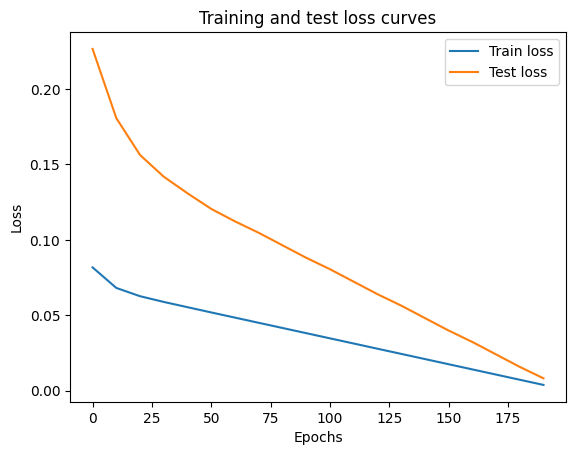

In [163]:
# Plot the loss curve
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [129]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [137]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [141]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6962])), ('bias', tensor([0.3064]))])

In [138]:
weight, bias

(0.7, 0.3)

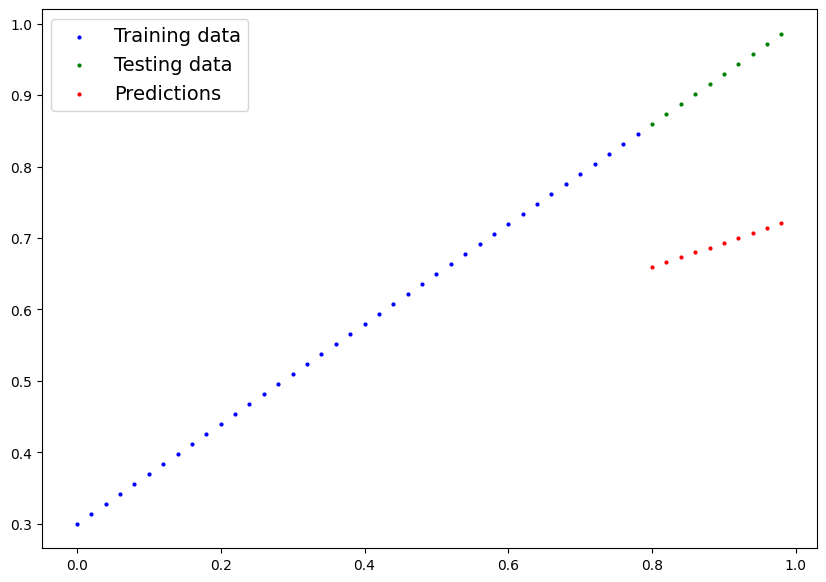

In [139]:
plot_predictions(predictions=y_preds);

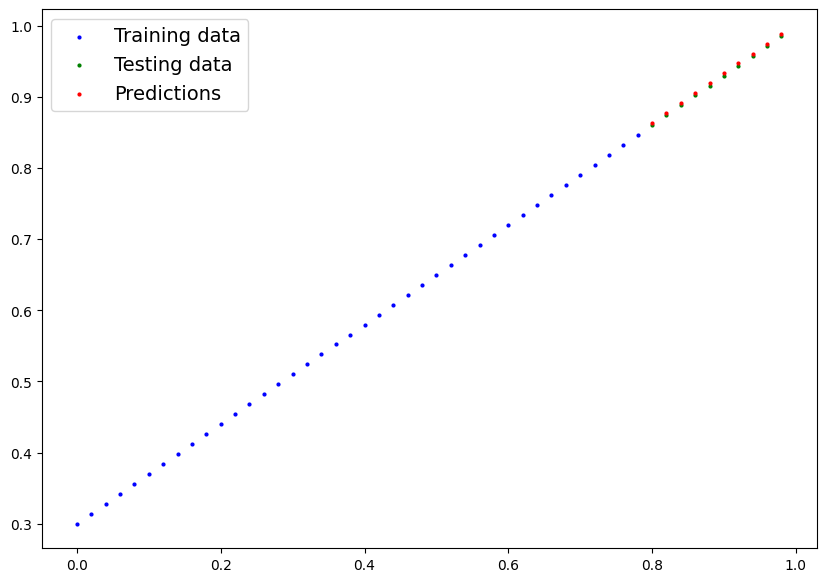

In [140]:
plot_predictions(predictions=y_preds_new);